<a href="https://colab.research.google.com/github/Mahi200728/CareerPath/blob/main/Unit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how much time you'll spend studying on a given day, using the amount of sleep you got the night before as a predictor.

If this seems to easy, then add another variable or two (test tomorrow? activity after school?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?

A decision tree is essentially a flow chart that helps represent the choices and the effects of them in a phyisical model. They use root nodes as the parent functions and then have many internal nodes that act as the layers of the tree.

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

The depth is essentially the number of decisions the tree has to make (how many questions the tree is asking before the final answer). We know it might be too deep if it starts overfitting because it is too based in the training data. We know if its not deep enought also by the amount of questions asked and how complex they are which is underfitting.

**Task4:**

How are BART models similar and different from a decision tree?

BART models and decision trees are similar ideas but they work differently.

Similarities:


*   Tree models
*   They learn from the patterns of the data rather than parameters.

Differences:


*   Bart uses multiple trees while decision only uses one
*   bart has built in bayesian regulation while deciosion has a max depth
* decision is easier to understand because there is only one main tree





**Task5**:

Why would we use a BART model instead of a decision tree?

Bart would be used when you need to understand a complex situation with multiple factors. Also really useful if you are super uncertian. There also is built in bayseian regulation which helps it self-adjust.

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [1]:
!pip install pymc-bart
!pip install preliz

In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc_bart as pmb
import preliz as pz
import seaborn as sns

In [3]:
from sklearn import tree

In [4]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()

In [14]:
X = penguins[['flipper_length',
              'bill_depth',
              'bill_length',
]]
Y = penguins["body_mass"].to_numpy()

In [15]:
with pm.Model() as model_penguinR:
    s = pm.HalfNormal('s', 20)
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50)
    μ = pm.Deterministic("μ",pm.math.exp(μ_))
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y)
    idata_penguinR = pm.sample(compute_convergence_checks=False)

Output()

Output()

<Axes: xlabel='y'>

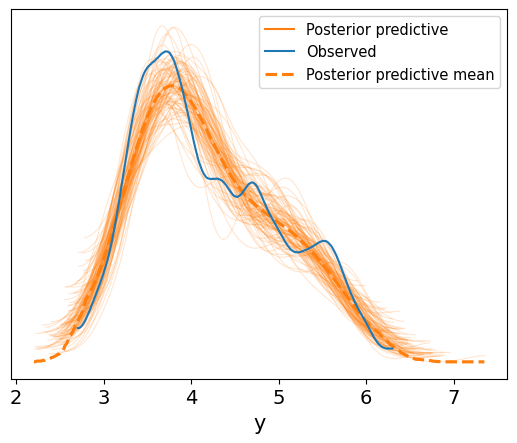

In [16]:
#generate the posterior predictive dist
pm.sample_posterior_predictive(idata_penguinR,model_penguinR, extend_inferencedata=True)
az.plot_ppc(idata_penguinR, num_pp_samples=100, colors=["C1", "C0", "C1"])

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

In [22]:
X = penguins["flipper_length"].to_numpy().reshape(-1, 1)
Y = penguins["body_mass"].to_numpy()

In [23]:
with pm.Model() as model_penguin:
    s = pm.HalfNormal('s', 20)
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50)
    μ = pm.Deterministic("μ",pm.math.exp(μ_))
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y)
    idata_penguin = pm.sample(compute_convergence_checks=False)

Output()

Output()

<Axes: xlabel='y'>

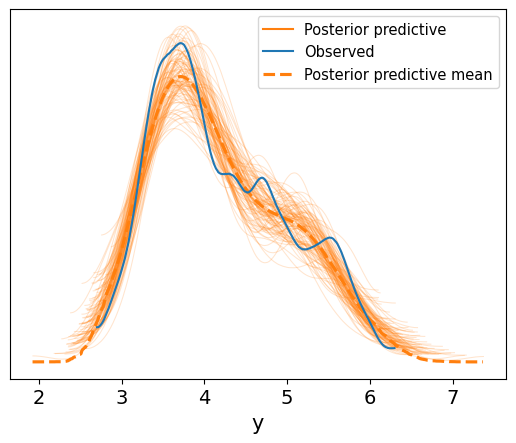

In [24]:
#generate the posterior predictive dist
pm.sample_posterior_predictive(idata_penguin,model_penguin, extend_inferencedata=True)
az.plot_ppc(idata_penguin, num_pp_samples=100, colors=["C1", "C0", "C1"])

In [25]:
posterior_mean = idata_penguin.posterior["μ"]

μ_hdi = az.hdi(ary=idata_penguin, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_penguin, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.11/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


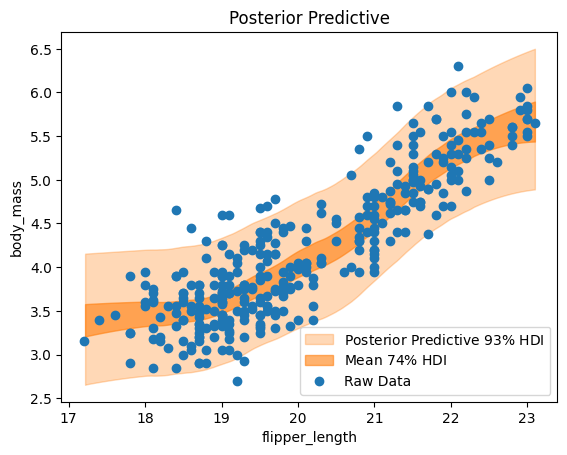

In [26]:
idx = np.argsort(X[:, 0])
fig, ax = plt.subplots()

az.plot_hdi(
    x=X[:, 0],
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior Predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=X[:, 0],
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)
ax.plot(penguins["flipper_length"], penguins["body_mass"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="flipper_length",
    ylabel="body_mass",
);

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

I think it captures the association between flipper length and body mass really well as majority of the data points fall inside the posterior predictive HDI which means that the model is predicting pretty well as it follows the trend upward of both the HDIs. It also seems to be more confident about the data in the middle around the average but less towards either extreme which is shown by the widening of the HDI bits. It also isn't fully linear as it curves above 19 and 21 flipper length. This means that there might be other factors that affect the bodymass.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_length'>], dtype=object)

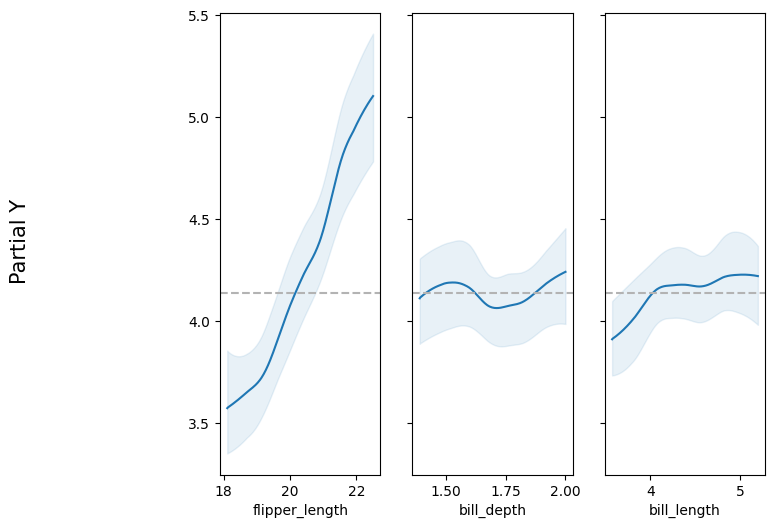

In [17]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_length'>], dtype=object)

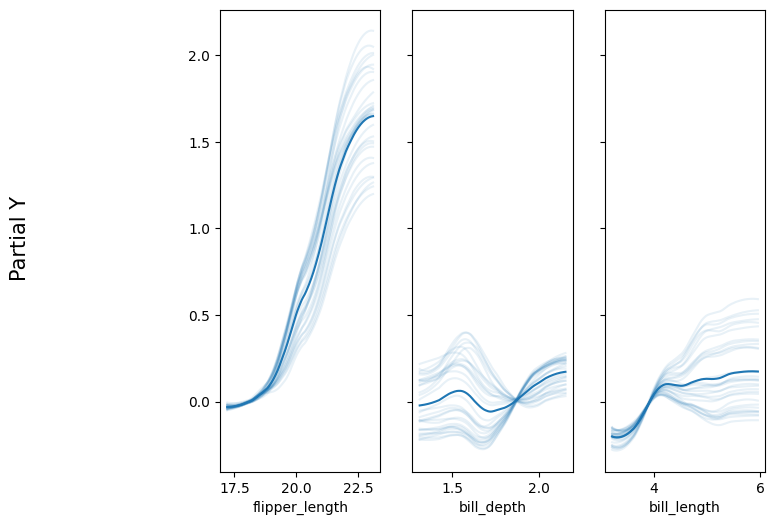

In [18]:
pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

In [19]:
vi_penguin = pmb.compute_variable_importance(idata_penguinR, μ_, X)

<Axes: ylabel='R²'>

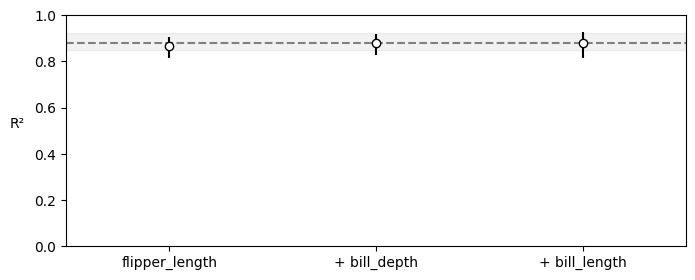

In [20]:
pmb.plot_variable_importance(vi_penguin)

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

Overall with all three types of graphs it looks like flipper length was the most imporant predictor of bodymass. In the variable importance graph it has the highest importance score which means it has the strongest impact. the PDP helps us understand the effect of the variables where flipper length shows the most clear relationship as well as mostly linear making it most the predictable. On the other hand bill length and depth didn't show a very clear relationship and were mainly nonlinear. The ICE plot for flipper length was pretty consistantly upward which matches the PDP but the variation of the slopes shows that there might be other factors influencing body mass. Bill length and depth show a lot more differences which matches what I said earlier, being that they probably aren't the best predictors.